In [ ]:
import os
import sys
import numpy as np
import seaborn as sns 
import pandas as pd
import matplotlib.pyplot as plt
import nipes_data_fcts as nidf
import me_data_fcts as medf
import pacmap


/home/leni/.local/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


In [3]:
import importlib
importlib.reload(medf)

<module 'me_data_fcts' from '/home/leni/git/AREFramework/experiments/scripts/me_data_fcts.py'>

In [ ]:
repo_folder = "/media/leni/DATADRIVE1/gecco_2025_data/meim_sq_env/"
corr_folder = repo_folder + "corridor/"
hill_folder = repo_folder + "hill/"
t1_folder = repo_folder + "terrain_1/"
t3_folder = repo_folder + "terrain_3/"

In [ ]:
training_data1 = []
training_data2 = []
training_data3 = []
sq_data_lines = []
for folder in os.listdir(corr_folder):
    print(folder)
    sq_data = medf.load_quadrics_params(corr_folder + "/" + folder + "/quadrics.csv")
    ids, parents, fitnesses, evals, deltas = medf.load_fitness(corr_folder + "/" + folder + "/fitness.csv")
    descriptors = medf.load_feature_descriptor(corr_folder + "/" + folder + "/morph_features.csv")
    for d,p,f,desc in zip(sq_data,parents,fitnesses,descriptors):
        training_data1.append(d[3] + d[4] + d[5] + d[6])
        training_data2.append(desc[1:8])
        training_data3.append(desc[1:8] + d[3] + d[4] + d[5] + d[6])
        sq_data_lines.append(d + desc[1:5] + [desc[5]*16,desc[6]*16,desc[7]*16,desc[8]*16] + [p,f,"corridor"])
for folder in os.listdir(hill_folder):
    print(folder)
    sq_data = medf.load_quadrics_params(hill_folder + "/" + folder + "/quadrics.csv")
    ids, parents, fitnesses, evals, deltas = medf.load_fitness(hill_folder + "/" + folder + "/fitness.csv")
    descriptors = medf.load_feature_descriptor(hill_folder + "/" + folder + "/morph_features.csv")
    for d,p,f,desc in zip(sq_data,parents,fitnesses,descriptors):
        training_data1.append(d[3] + d[4] + d[5] + d[6])
        training_data2.append(desc[1:8])
        training_data3.append(desc[1:8] + d[3] + d[4] + d[5] + d[6])        
        sq_data_lines.append(d + desc[1:5] + [desc[5]*16,desc[6]*16,desc[7]*16,desc[8]*16] + [p,f,"hill"])

for folder in os.listdir(t1_folder):
    print(folder)
    sq_data = medf.load_quadrics_params(t1_folder + "/" + folder + "/quadrics.csv")
    ids, parents, fitnesses, evals, deltas = medf.load_fitness(t1_folder + "/" + folder + "/fitness.csv")
    descriptors = medf.load_feature_descriptor(t1_folder + "/" + folder + "/morph_features.csv")
    for d,p,f,desc in zip(sq_data,parents,fitnesses,descriptors):
        training_data1.append(d[3] + d[4] + d[5] + d[6])
        training_data2.append(desc[1:8])
        training_data3.append(desc[1:8] + d[3] + d[4] + d[5] + d[6])        
        sq_data_lines.append(d + desc[1:5] + [desc[5]*16,desc[6]*16,desc[7]*16,desc[8]*16] + [p,f,"terrain_1"])

for folder in os.listdir(t3_folder):
    print(folder)
    sq_data = medf.load_quadrics_params(t3_folder + "/" + folder + "/quadrics.csv")
    ids, parents, fitnesses, evals, deltas = medf.load_fitness(t3_folder + "/" + folder + "/fitness.csv")
    descriptors = medf.load_feature_descriptor(t3_folder + "/" + folder + "/morph_features.csv")
    for d,p,f,desc in zip(sq_data,parents,fitnesses,descriptors):
        training_data1.append(d[3] + d[4] + d[5] + d[6])
        training_data2.append(desc[1:8])
        training_data3.append(desc[1:8] + d[3] + d[4] + d[5] + d[6])
        sq_data_lines.append(d + desc[1:5] + [desc[5]*16,desc[6]*16,desc[7]*16,desc[8]*16] + [p,f,"terrain_3"])

meim_13_1_15-41-30-500-3233918242
meim_13_1_15-41-32-2445-4018006180
meim_13_1_15-41-35-5446-3749279805
meim_13_1_22-0-10-29-3796841191
meim_14_1_10-54-6-6050-548654614
meim_14_1_11-8-18-8105-3878374608
meim_14_1_7-7-51-1136-553543978
meim_14_1_9-17-28-8123-1685589250
meim_14_1_9-53-6-6071-1642489664
meim_17_1_10-27-59-9592-2791438490
meim_13_1_15-40-41-1594-108794793
meim_13_1_15-41-12-2465-4256476871
meim_13_1_15-41-15-5513-1338402749
meim_13_1_15-41-6-6528-916123146
meim_13_1_15-41-9-9594-3945969860
meim_14_1_2-46-44-4574-2594070513
meim_14_1_4-0-5-5049-2531038674
meim_14_1_4-23-34-4063-4069383424
meim_14_1_4-56-2-2029-3799545906
meim_15_1_5-4-58-8982-3126583584
meim_13_1_22-16-1-1015-1248241595
meim_13_1_22-23-59-9007-2129664642
meim_13_1_22-28-48-8119-1285958447
meim_13_1_22-42-45-5047-119745660
meim_14_1_11-46-24-4155-4157087900
meim_14_1_11-9-22-2019-3870084127
meim_14_1_15-3-48-8894-1717012323
meim_14_1_17-11-17-7039-2241618117
meim_14_1_18-22-8-8099-2104441992
meim_17_1_10-27-

In [10]:
print(sq_data_lines[0][7:15])

[0.545455, 0.727273, 0.181818, 0.0225394, 1.0, 0.0, 2.0, 0.0]


In [5]:
model = pacmap.PaCMAP(n_components=2,n_neighbors=40)
embedding = model.fit_transform(training_data)

In [26]:
model2 = pacmap.PaCMAP(n_components=2,n_neighbors=40)
embedding2 = model2.fit_transform(training_data)

In [11]:
lines = []
for x,y,d in zip(embedding[:,0],embedding[:,1],sq_data_lines):
    lines.append([d[0],x,y,d[1],d[2],d[16]] + d[7:15] + [d[-1]])
df = pd.DataFrame(lines,columns=["id","pacmap_x","pacmap_y","sym_x","sym_y","fitness","width","depth","height","voxels","wheels","sensors","joints","casters","environment"])

In [27]:
lines = []
for x,y,d in zip(embedding2[:,0],embedding2[:,1],sq_data_lines):
    lines.append([d[0],x,y,d[1],d[2],d[16]] + d[7:15] + [d[-1]])
df2 = pd.DataFrame(lines,columns=["id","pacmap_x","pacmap_y","sym_x","sym_y","fitness","width","depth","height","voxels","wheels","sensors","joints","casters","environment"])

<Axes: xlabel='pacmap_x', ylabel='pacmap_y'>

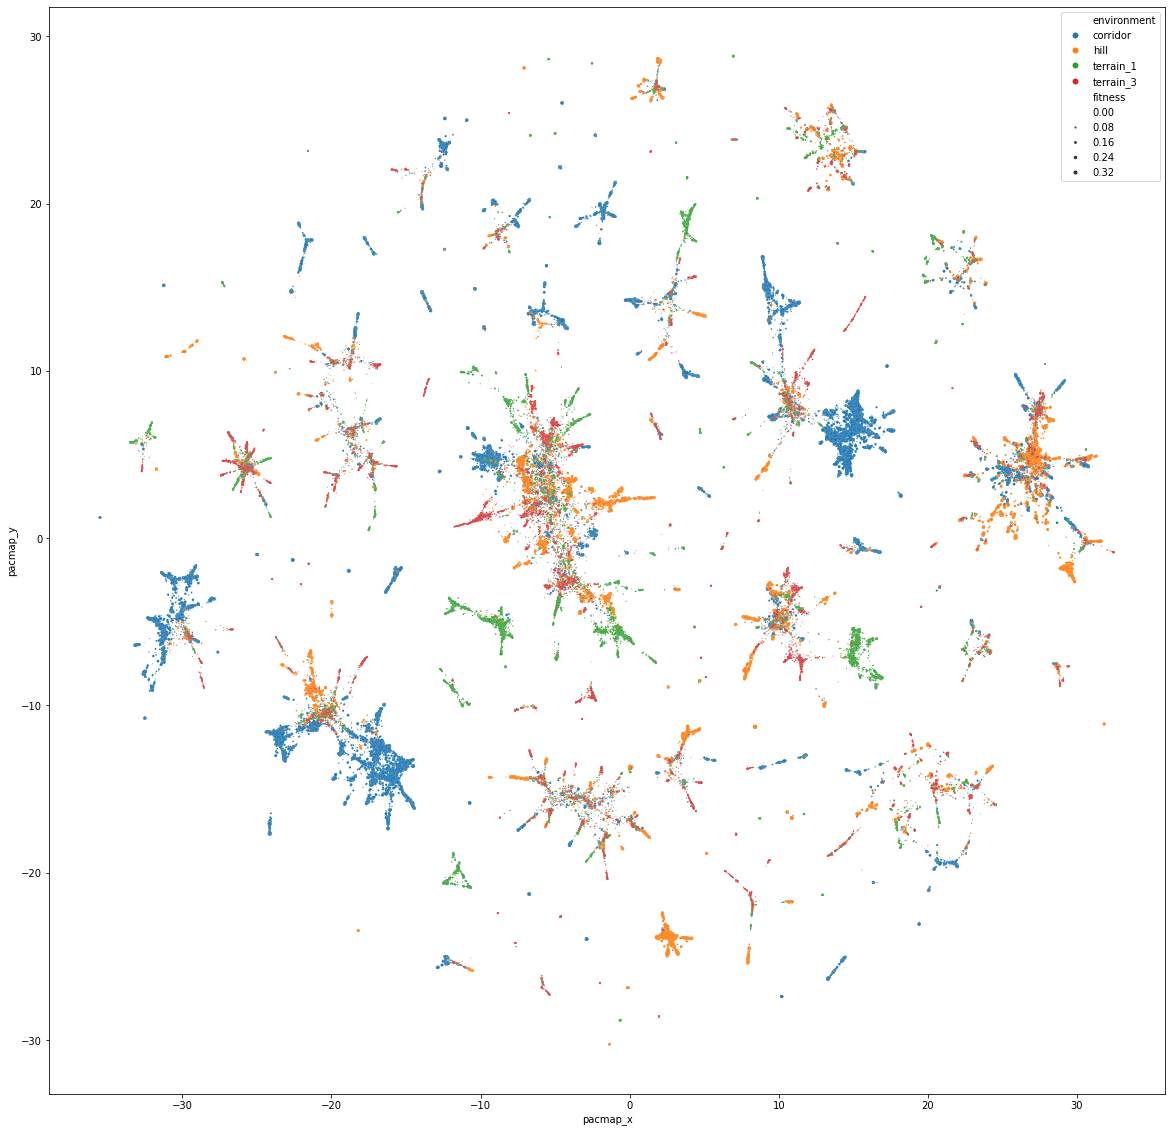

In [19]:
fig = plt.gcf()
fig.set_size_inches(20,20)
sns.scatterplot(df,x="pacmap_x",y="pacmap_y",size="fitness",sizes=(0,20),hue="environment")

<Axes: xlabel='pacmap_x', ylabel='pacmap_y'>

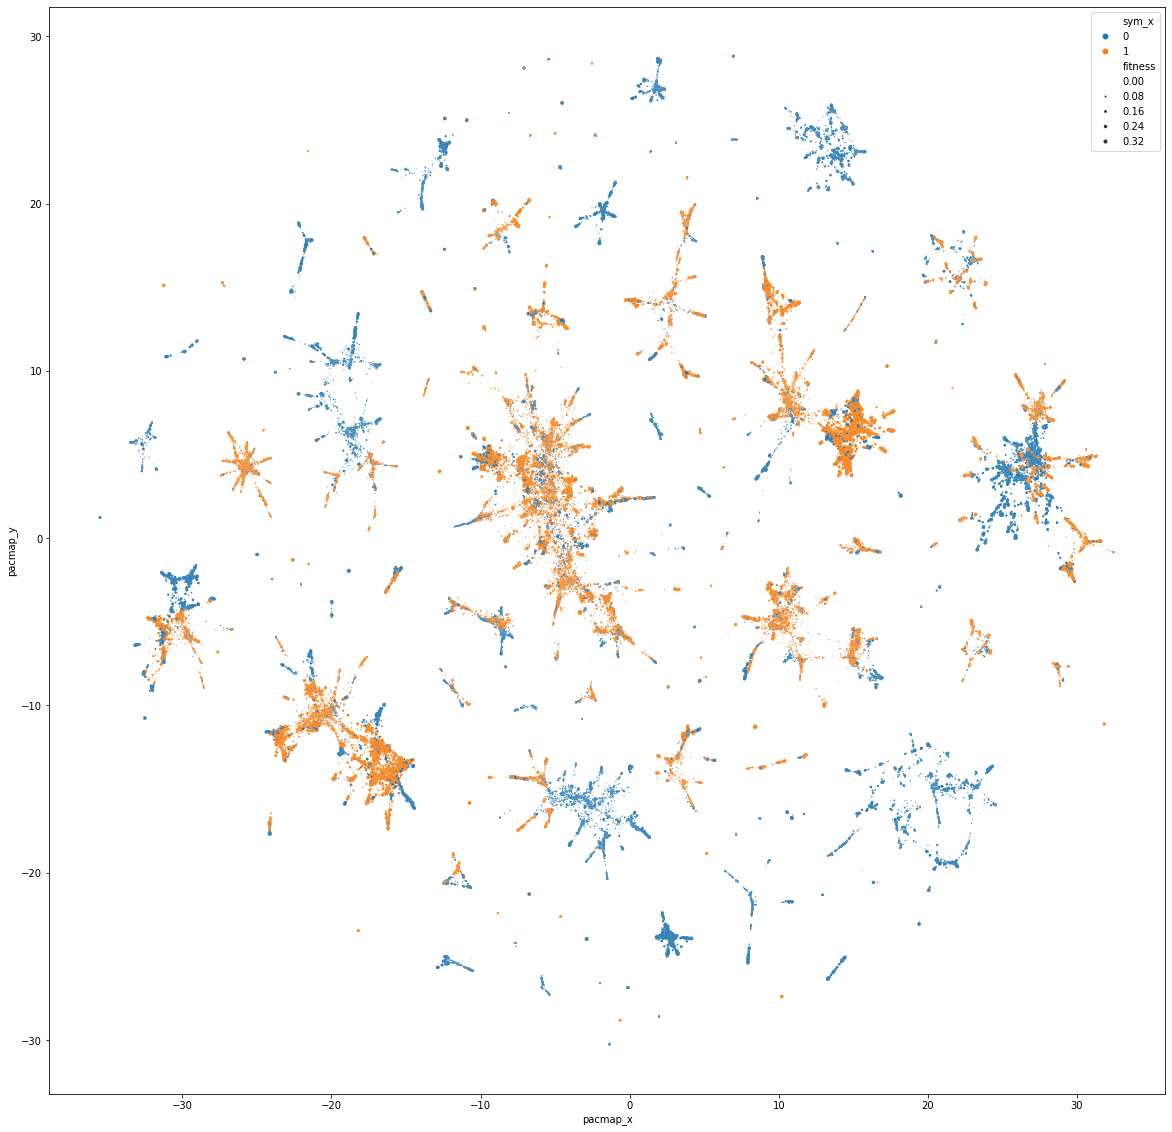

In [33]:
fig = plt.gcf()
fig.set_size_inches(20,20)
sns.scatterplot(df,x="pacmap_x",y="pacmap_y",size="fitness",sizes=(0,20),hue="sym_x")

<Axes: xlabel='pacmap_x', ylabel='pacmap_y'>

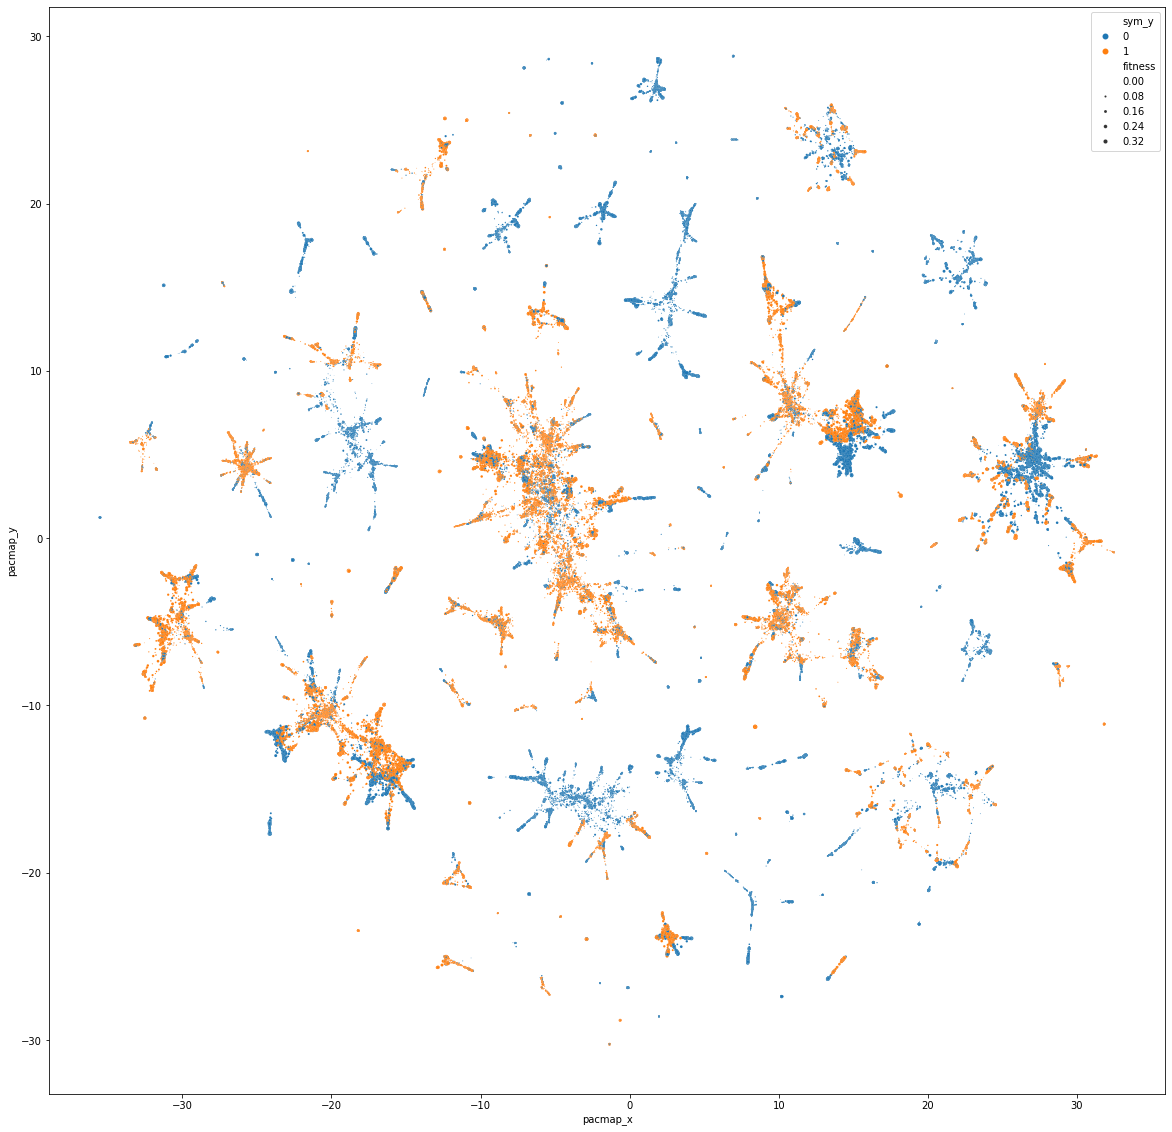

In [34]:
fig = plt.gcf()
fig.set_size_inches(20,20)
sns.scatterplot(df,x="pacmap_x",y="pacmap_y",size="fitness",sizes=(0,20),hue="sym_y")

<Axes: xlabel='pacmap_x', ylabel='pacmap_y'>

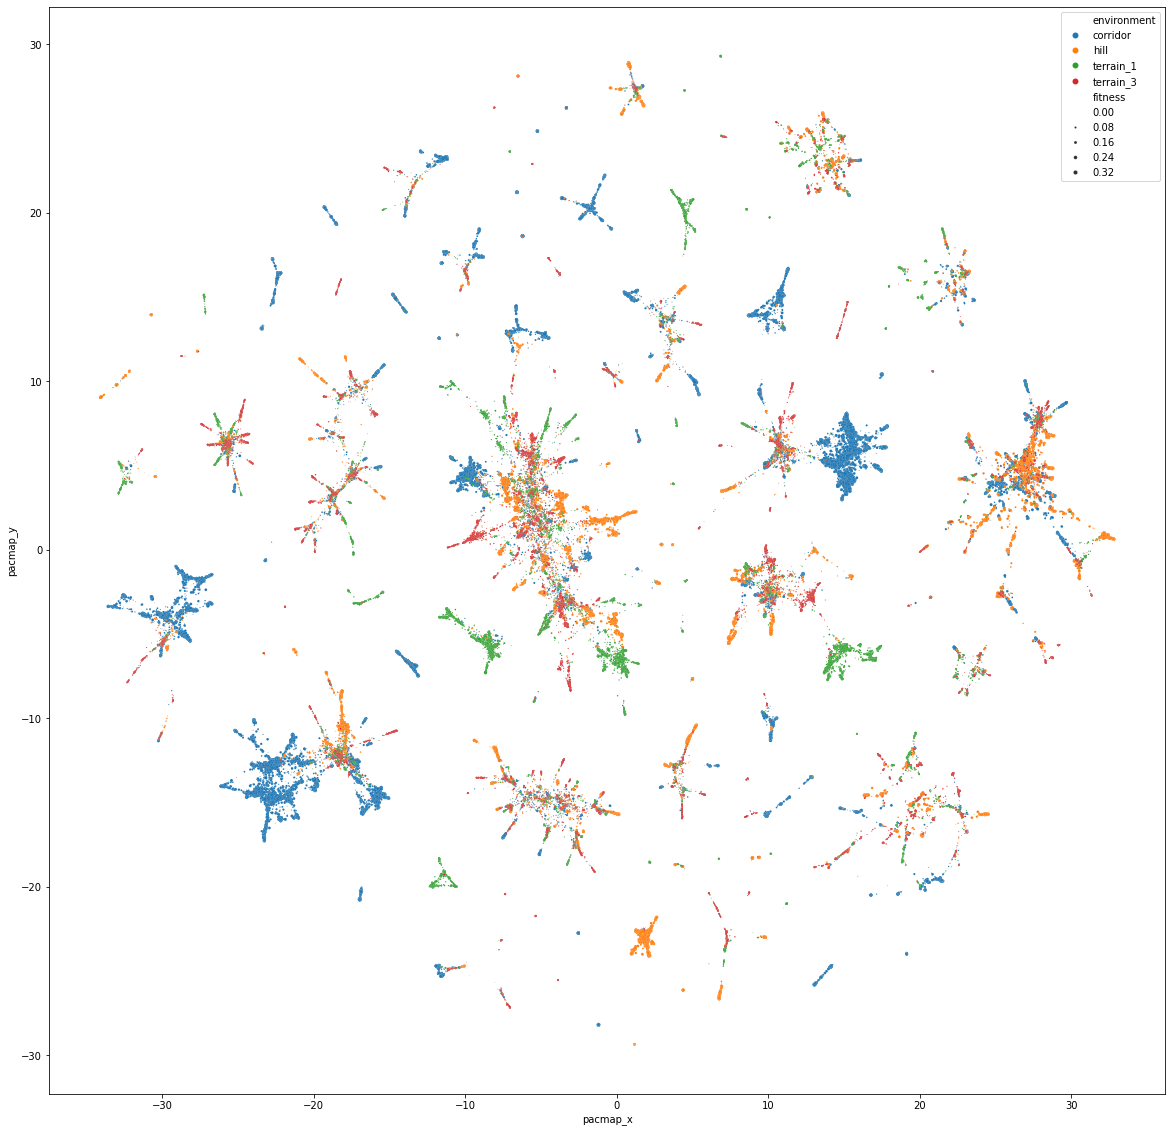

In [28]:
fig = plt.gcf()
fig.set_size_inches(20,20)
sns.scatterplot(df2,x="pacmap_x",y="pacmap_y",size="fitness",sizes=(0,20),hue="environment")

<Axes: xlabel='pacmap_x', ylabel='pacmap_y'>

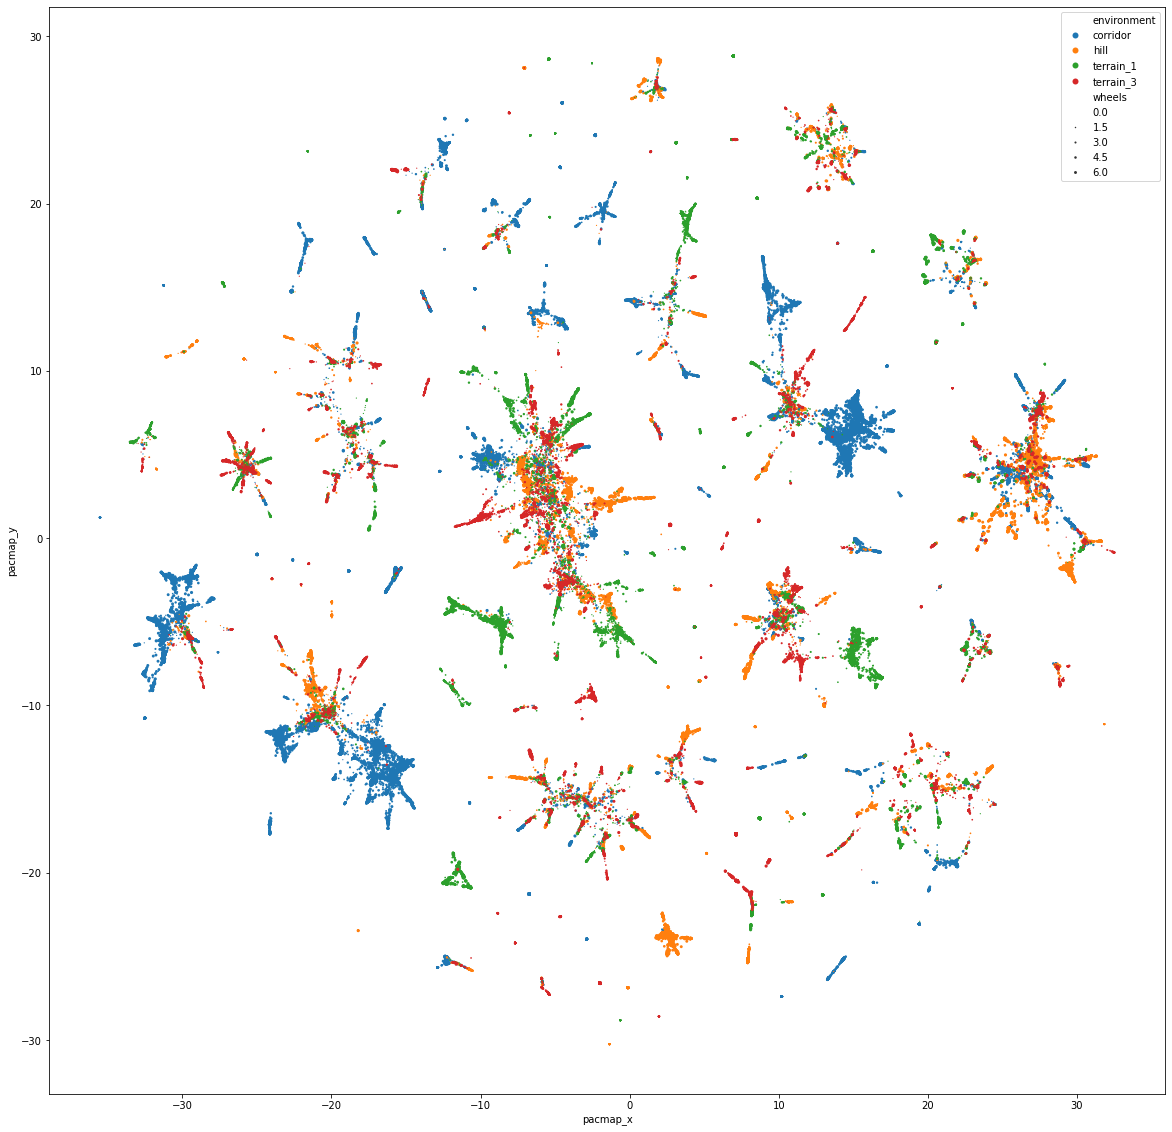

In [30]:
fig = plt.gcf()
fig.set_size_inches(20,20)
sns.scatterplot(df,x="pacmap_x",y="pacmap_y",size="wheels",sizes=(0,10),hue="environment")

<Axes: xlabel='pacmap_x', ylabel='pacmap_y'>

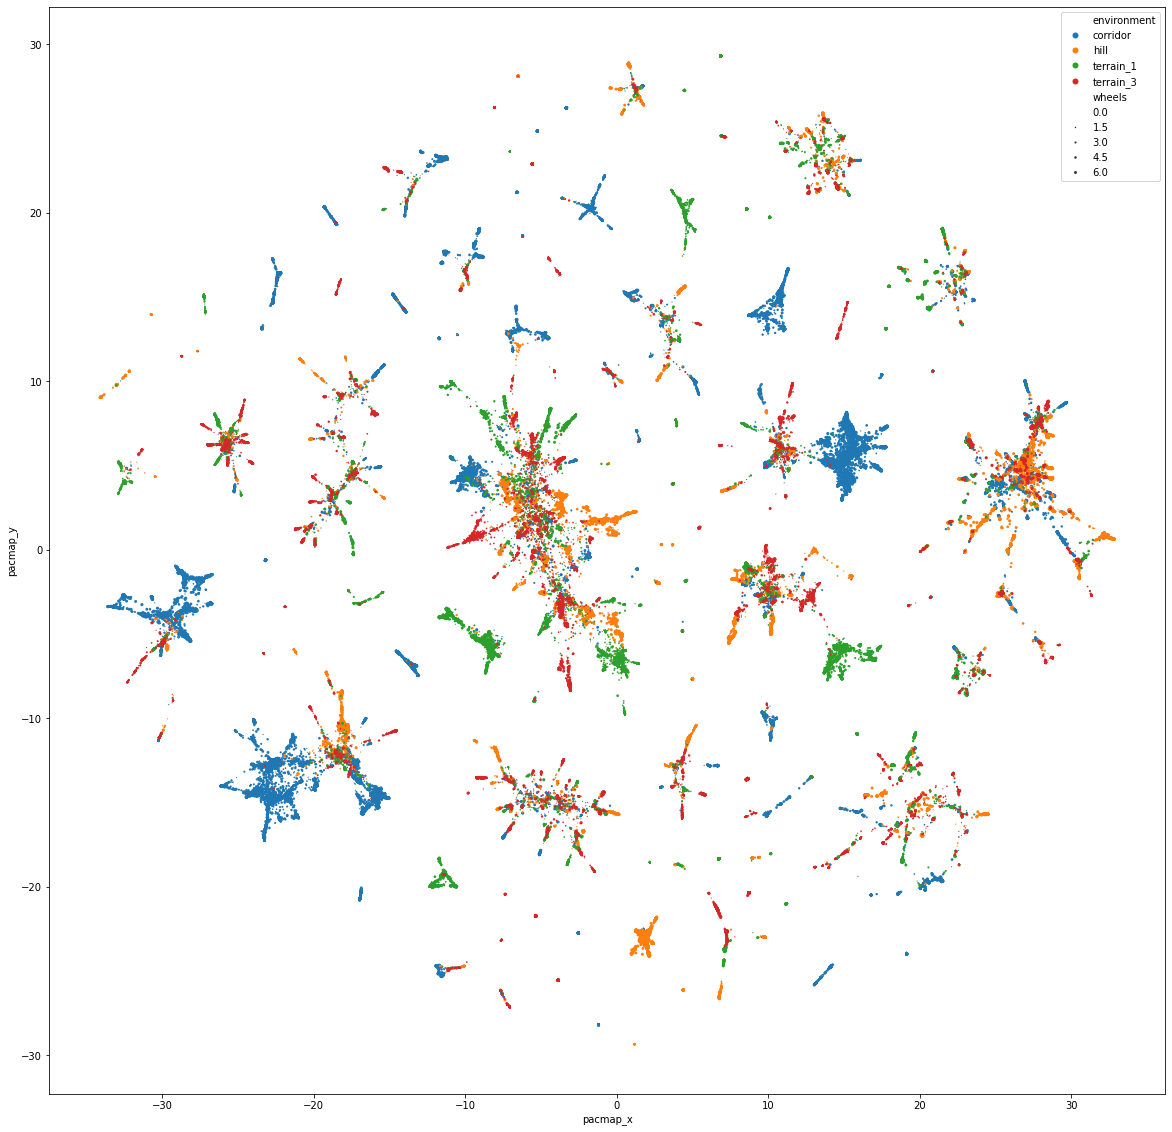

In [31]:
fig = plt.gcf()
fig.set_size_inches(20,20)
sns.scatterplot(df2,x="pacmap_x",y="pacmap_y",size="wheels",sizes=(0,10),hue="environment")

<Axes: xlabel='pacmap_x', ylabel='pacmap_y'>

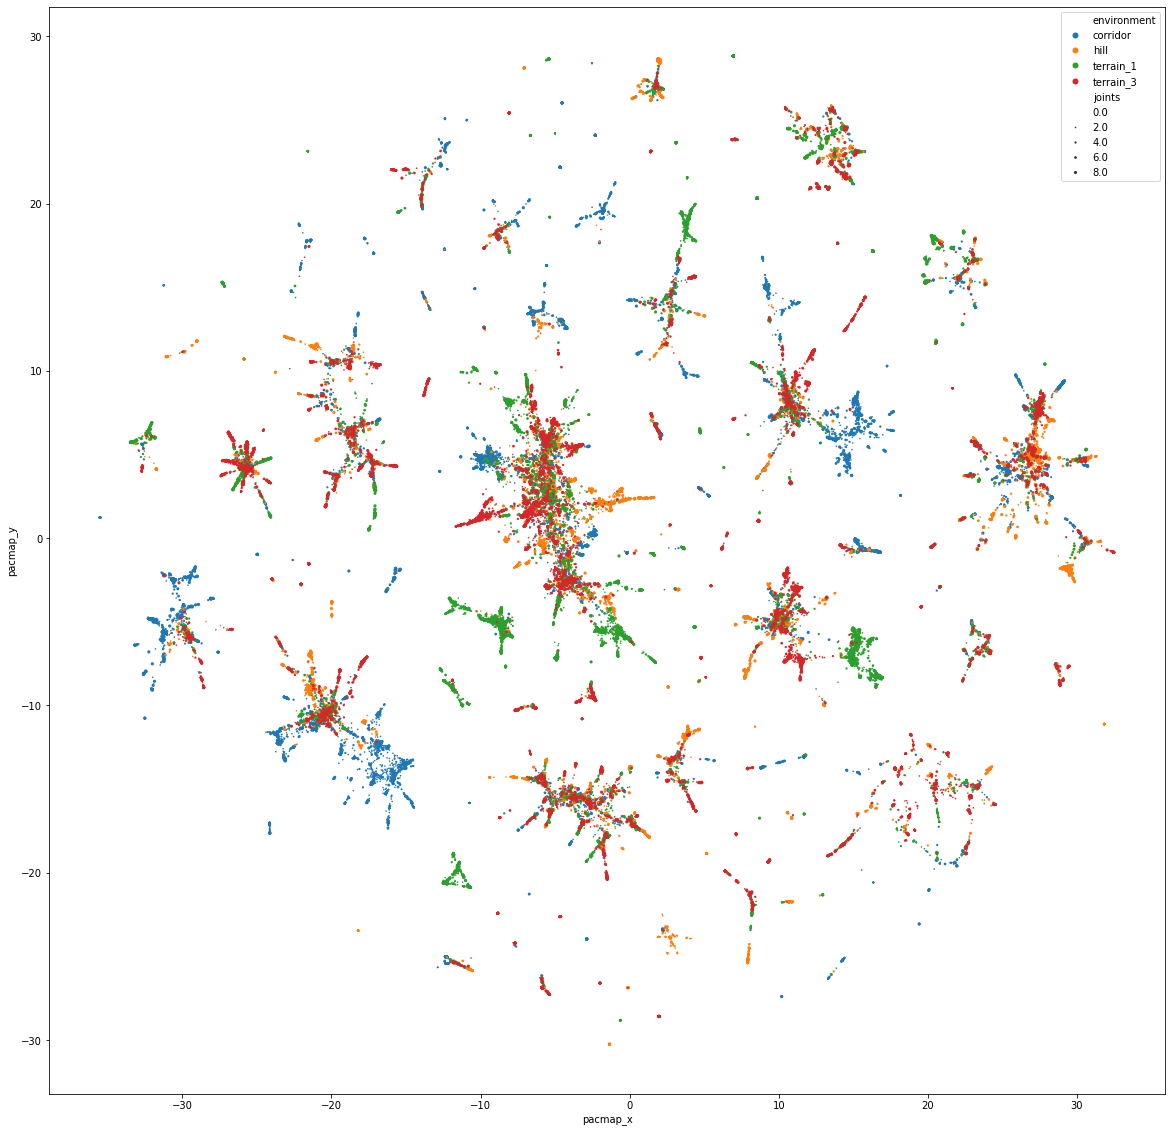

In [32]:
fig = plt.gcf()
fig.set_size_inches(20,20)
sns.scatterplot(df,x="pacmap_x",y="pacmap_y",size="joints",sizes=(0,10),hue="environment")

In [4]:
repo_folder = "/media/leni/DATADRIVE1/alife_2025/"
experiments = {
    "directory" :  ['meimflat', 'meimhill', 'meimholes', 'meimobs', 'meimrough', 'meimholly' ],
    "name" :       ['flat', 'hill', 'holes', 'obstacles', 'rough', 'hollyrood'],
    "print_name" : ['Flat', 'Hill', 'Holes', 'Obstacles', 'Rough', 'Hollyrood'],
}

In [11]:
training_data1 = []
training_data2 = []
training_data3 = []
sq_data_lines = []
for exp_folder,name in zip(experiments["directory"],experiments["name"]):
    for folder in os.listdir(repo_folder + "/" + exp_folder):
            for fold in os.listdir(repo_folder + "/" + exp_folder + "/" + folder):                    
                print(folder)
                sq_data = medf.load_quadrics_params(repo_folder + "/" + exp_folder + "/" + folder + "/" + fold + "/quadrics.csv")
                ids, parents, fitnesses, evals, deltas, rep_idx = medf.load_fitness(repo_folder + "/" + exp_folder + "/" + folder + "/" + fold +  "/fitness.csv")
                descriptors = medf.load_feature_descriptor(repo_folder + "/" + exp_folder + "/" + folder + "/" + fold + "/morph_features.csv")
                for d,p,f,desc in zip(sq_data,parents,fitnesses,descriptors):
                    training_data1.append(d[3] + d[4] + d[5] + d[6])
                    training_data2.append(desc[1:8])
                    training_data3.append(desc[1:8] + d[3] + d[4] + d[5] + d[6])
                    sq_data_lines.append(d + desc[1:5] + [desc[5]*16,desc[6]*16,desc[7]*16,desc[8]*16] + [p,f,name])

55742_1
55742_10
55742_2
55742_3
55742_4
55742_5
55742_6
55742_7
55742_8
55742_9
56265_1
56265_10
56265_2
56265_3
56265_4
56265_5
56265_6
56265_7
56265_8
56265_9
55751_1
55751_10
55751_2
55751_3
55751_4
55751_5
55751_6
55751_8
55751_9
56274_1
56274_10
56274_3
56274_4
56274_5
56274_6
56274_7
56274_8
56274_9
55750_1
55750_10
55750_2
55750_3
55750_4
55750_5
55750_6
55750_7
55750_8
55750_9
56275_1
56275_10
56275_2
56275_3
56275_4
56275_5
56275_6
56275_7
56275_8
56275_9
55752_1
55752_10
55752_2
55752_3
55752_4
55752_5
55752_6
55752_7
55752_8
55752_9
56277_1
56277_10
56277_2
56277_3
56277_4
56277_5
56277_6
56277_8
56277_9
56221_1
56221_10
56221_2
56221_3
56221_4
56221_5
56221_6
56221_7
56221_8
56221_9
56278_1
56278_10
56278_2
56278_3
56278_4
56278_5
56278_6
56278_7
56278_9
56214_1
56214_10
56214_2
56214_3
56214_4
56214_5
56214_6
56214_7
56214_8
56214_9
56276_1
56276_10
56276_2
56276_3
56276_4
56276_5
56276_6
56276_7
56276_8
56276_9


In [6]:
import pickle

In [7]:
model1 = pacmap.PaCMAP(n_components=2,n_neighbors=40)
embedding1 = model1.fit_transform(training_data1)
pickle.save(model1,"pacmap_model1.pkl")
pickle.save(embedding1,"pacmap_embedding1.pkl")


AttributeError: module 'pickle' has no attribute 'save'

In [25]:
lines = []
for x,y,d in zip(embedding1[:,0],embedding1[:,1],sq_data_lines):
    lines.append([d[0],x,y,d[1],d[2],d[16]] + d[7:15] + [d[-1]])
df1 = pd.DataFrame(lines,columns=["id","pacmap_x","pacmap_y","sym_x","sym_y","fitness","width","depth","height","voxels","wheels","sensors","joints","casters","environment"])

<Axes: xlabel='pacmap_x', ylabel='pacmap_y'>

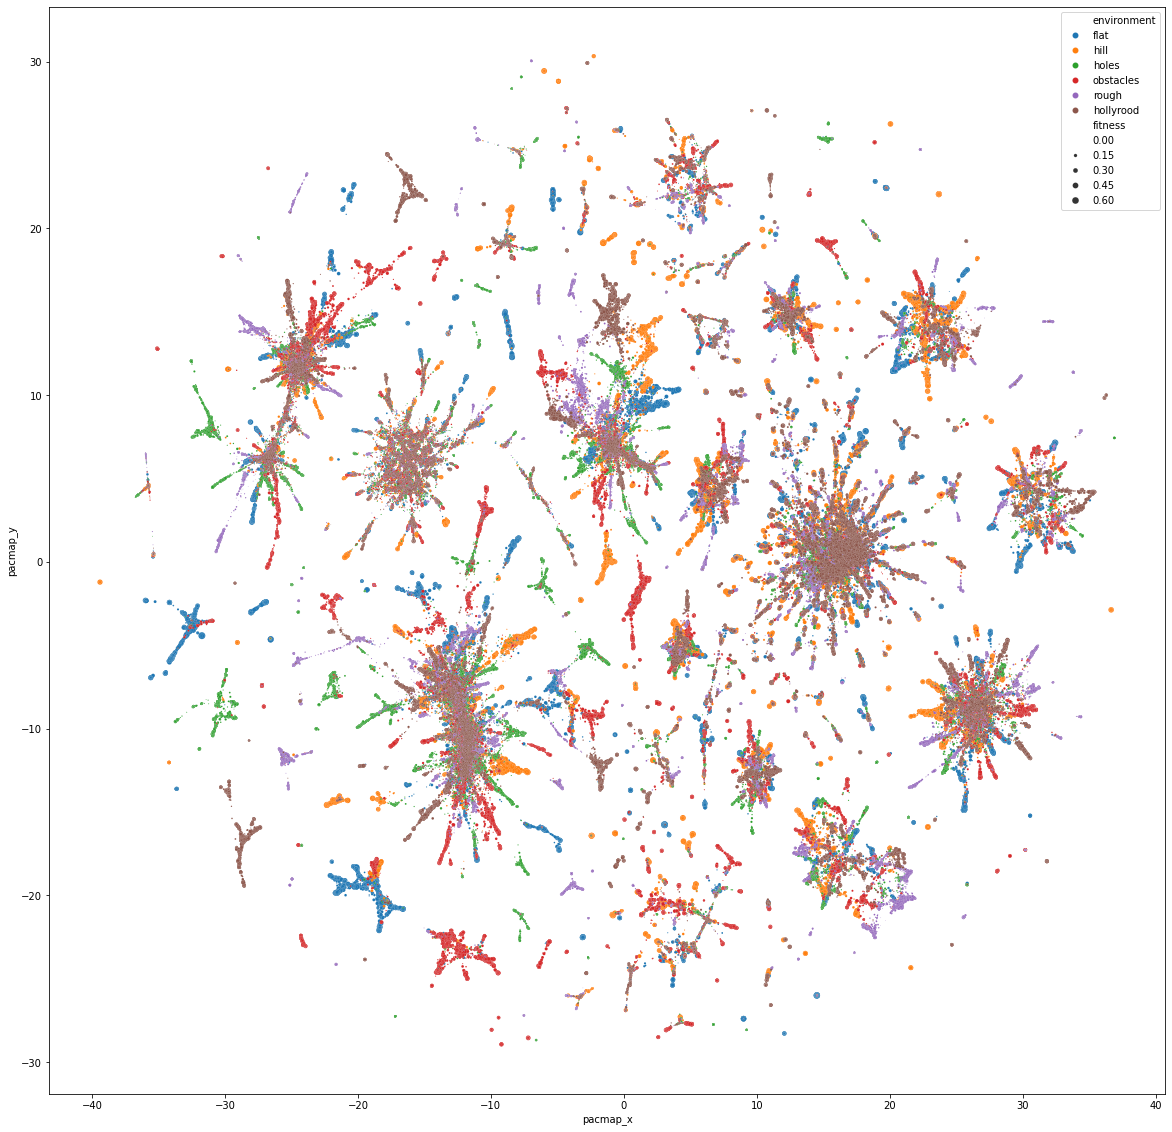

In [26]:
fig = plt.gcf()
fig.set_size_inches(20,20)
sns.scatterplot(df1,x="pacmap_x",y="pacmap_y",size="fitness",sizes=(0,20),hue="environment")

In [29]:
model2 = pacmap.PaCMAP(n_components=2,n_neighbors=40)
embedding2 = model2.fit_transform(training_data2)

In [19]:
model3 = pacmap.PaCMAP(n_components=2,n_neighbors=40)
embedding3 = model3.fit_transform(training_data3)

In [23]:
lines = []
for x,y,d in zip(embedding3[:,0],embedding3[:,1],sq_data_lines):
    lines.append([d[0],x,y,d[1],d[2],d[16]] + d[7:15] + [d[-1]])
df3 = pd.DataFrame(lines,columns=["id","pacmap_x","pacmap_y","sym_x","sym_y","fitness","width","depth","height","voxels","wheels","sensors","joints","casters","environment"])

<Axes: xlabel='pacmap_x', ylabel='pacmap_y'>

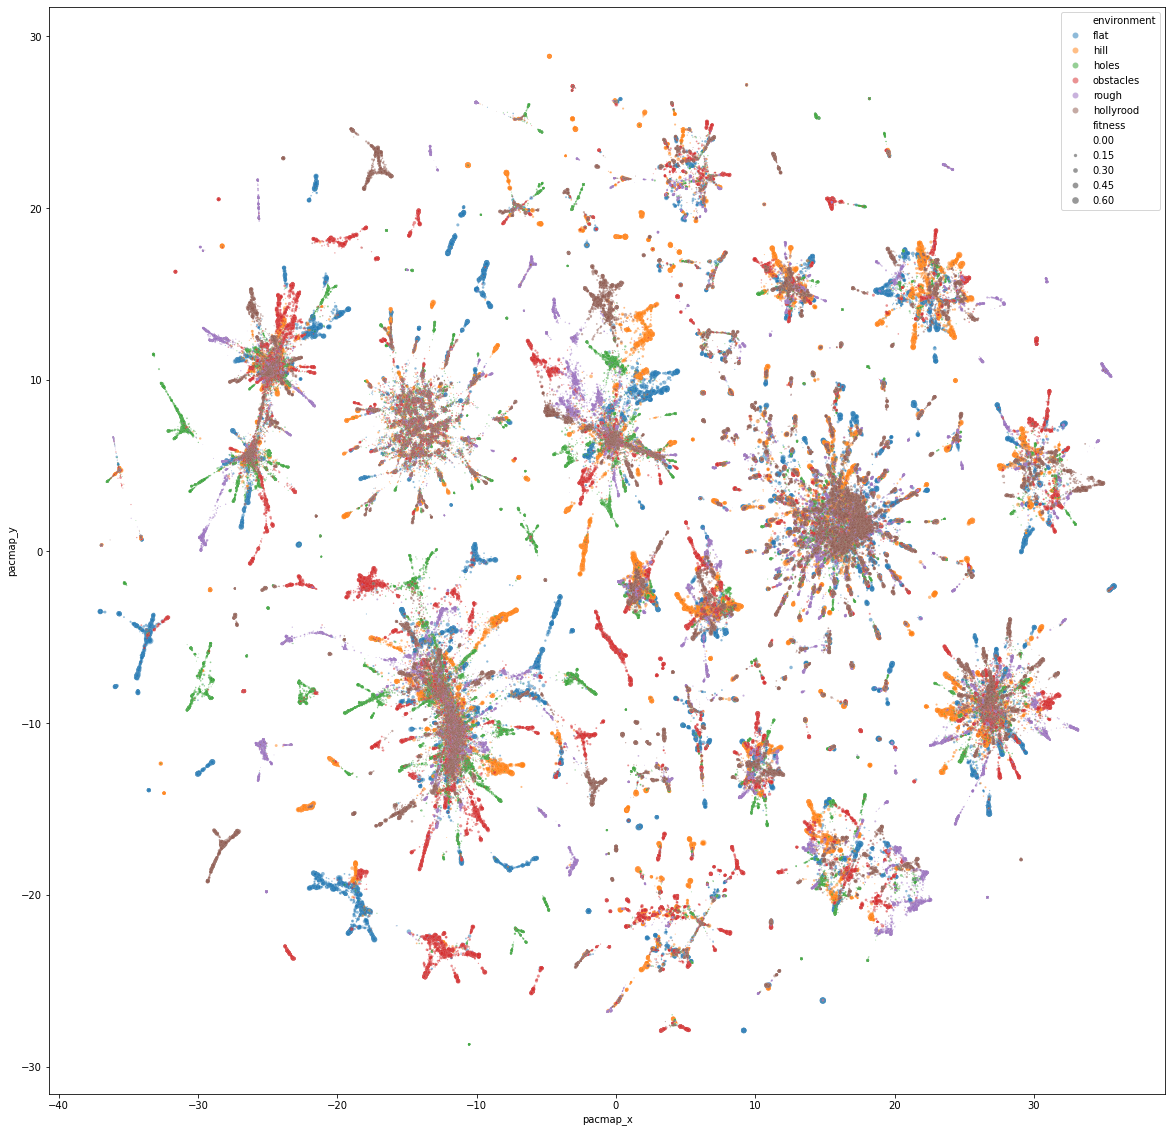

In [28]:
fig = plt.gcf()
fig.set_size_inches(20,20)
sns.scatterplot(df3,x="pacmap_x",y="pacmap_y",size="fitness",sizes=(0,50),hue="environment",alpha=0.5)